<div style="text-align: center;">

**Content Produced by UF Signal Processing Society**

**Authors: Raul Valle**
</div>

<div style="text-align: center;">

# Foundations of Signal Processing (1)

</div>

<div style="text-align: center;">

We will be learning about the theory behind representations for signals from a historical point of view, as well as its formulation since.

</div>

<div style="text-align: center;">

### Acknowledgements

</div>

<div style="text-align: center;">

I'd like to thank UF and SPS for their interest in IEEE SPS, giving everyone a platform to share their knowledge and resources.

Finally, I'd like to thank Dr. Principe, Dr. Silva, Dr. Wong, Dr. Shea, Benjamin Colburn, Matheus Kunzler Maldaner, Evan Partidas, my family and IEEE SPS for their continual support in my academic journey.

</div>

<div style="text-align: center;">

## 0. Introduction

</div>

<div style="text-align: center;">

First, I want to clear up that I will be using the terms **Signal Processing** and **Machine Learning** almost interchangeabbly because they are based on the same principles of calculus and statistics for the most part.

As technology improves, computationally intense applications like Signal Processing and Machine Learning have become more viable.

Specifically, real-time signal processing has become significantly more viable due to these improvements in computing power.

Signal Processing is important because it is the only means by which machines can interpret the world around them in a human-interpretable manner (aka through the explicit use of mathematics).

</div>

<div style="text-align: center;">

## 1. Pre-requisites

<div style="text-align: center;">

To understand the theory well, I suggest having a strong Algebraic and Geometric intuition.

If you are doing this in *Google Colabs*, then you will not need to set-up your environment. If you are not, then it is suggested that you use *Conda* to manage the packages for you, otherwise as long as you have sci-kit learn, numpy and matplotlib, you will be fine. 

</div>

In [1]:
import numpy as np
import matplotlib.pyplot as plt

<div style="text-align: center;">

### 1.0. Euler's Magic Number $e$

</div>

<div style="text-align: center;">

If you are in any STEM field, it should be no surprise that $e$ is a really special number. But a question you probably have never asked yourself is why? We will inspect it to understand it.

First, let's define the original equation:

$$
e = \lim_{n \to \infty} (1 + \frac{1}{n})^{n}
$$

By binomial expansion, we can express the right-hand expression:

$$
e = \lim_{n \to \infty} \sum_{i=0}^{n} \binom{n}{i} (1)^{n-i} \frac{1}{n^i} = \lim_{n \to \infty} \sum_{i=0}^{n} \binom{n}{i} \frac{1}{n^i}
$$

Recall that the expansion of the **choose** operator is:

$$
\binom{n}{i} = \frac{(n)(n-1)...(n-i+1)}{i!} \le \frac{n^i}{i!}
$$

If the expanded sum for $e$ converges for the **upper-bounded** sum, then e should converge as well.

$$
e = \lim_{n \to \infty} \sum_{i=0}^{n} \binom{n}{i} \frac{1}{n^i} \le \lim_{n \to \infty} \sum_{i=0}^{n} \frac{n^i}{i!} \frac{1}{n^i} = \lim_{n \to \infty} \sum_{i=0}^{n} \frac{1}{i!}
$$

Thankfully, computers exist and are able to express e precisely.

</div>

In [4]:
N = 20 # Number of terms used in the approximation
e_approximation = 1
calculated_factor = 1
for i in range(1,N):
    calculated_factor /= i
    e_approximation += calculated_factor
    print(f"Approximation of e using {i} terms: {e_approximation}")
print("Approximation of e using", N, "terms:", e_approximation)



Approximation of e using 1 terms: 2.0
Approximation of e using 2 terms: 2.5
Approximation of e using 3 terms: 2.6666666666666665
Approximation of e using 4 terms: 2.708333333333333
Approximation of e using 5 terms: 2.7166666666666663
Approximation of e using 6 terms: 2.7180555555555554
Approximation of e using 7 terms: 2.7182539682539684
Approximation of e using 8 terms: 2.71827876984127
Approximation of e using 9 terms: 2.7182815255731922
Approximation of e using 10 terms: 2.7182818011463845
Approximation of e using 11 terms: 2.718281826198493
Approximation of e using 12 terms: 2.7182818282861687
Approximation of e using 13 terms: 2.7182818284467594
Approximation of e using 14 terms: 2.71828182845823
Approximation of e using 15 terms: 2.718281828458995
Approximation of e using 16 terms: 2.718281828459043
Approximation of e using 17 terms: 2.7182818284590455
Approximation of e using 18 terms: 2.7182818284590455
Approximation of e using 19 terms: 2.7182818284590455
Approximation of e us

<div style="text-align: center;">

## 2. Signals Theory

<div style="text-align: center;">

### 2.0 Pre-requisites

</div>

<div style="text-align: center;">

#### 2.0.0 Notation & Definitions

</div>

<div style="text-align: center;">

For the following section, let's standardize some notation:

$$
x[t] \text{ is a discrete-time signal: } \forall t \in \mathbb{Z}, \ \exists x[t] \in \mathbb{C}
$$

$$
x(t) \text{ is a continuous-time signal: } \forall t \in \mathbb{R}, \ \exists x(t) \in \mathbb{C}
$$

The notation $x[t]$ and $x(t)$ refer to the value of the signal at a specific discrete or continuous-time instant, respectively. The entire collection of values over time constitutes the *signal* or *waveform*.

The function spaces are defined as follows:

$$
\ell_1 = \{ x[t] : \sum_{t=-\infty}^{\infty} |x[t]| < \infty \}
$$

$$
\ell_2 = \{ x[t] : \sum_{t=-\infty}^{\infty} |x[t]|^2 < \infty \}
$$

$$
L_1 = \{ x(t) : \int_{-\infty}^{\infty} |x(t)| dt < \infty \}
$$

$$
L_2 = \{ x(t) : \int_{-\infty}^{\infty} |x(t)|^2 dt < \infty \}
$$

A discrete-time signal is *absolutely summable* if: 

$$
\sum_{t=-\infty}^{\infty} |x[t]| < \infty \quad \Rightarrow \quad x[t] \in \ell_1
$$

A discrete-time signal has *finite energy* if: 

$$
\sum_{t=-\infty}^{\infty} |x[t]|^2 < \infty \quad \Rightarrow \quad x[t] \in \ell_2
$$

A continuous-time signal is *absolutely integrable* if:

$$
\int_{-\infty}^{\infty} |x(t)| dt < \infty \quad \Rightarrow \quad x(t) \in L_1
$$

A continuous-time signal is *square integrable* (or *finite energy*) if:

$$
\int_{-\infty}^{\infty} |x(t)|^2 dt < \infty \quad \Rightarrow \quad x(t) \in L_2
$$

For discrete-time signals, we have the inclusion:

$$
\ell_1 \subseteq \ell_2
$$

since

$$
|x[t]|^2 \leq |x[t]|, \quad \forall |x[t]| \leq 1.
$$

For continuous-time signals, we have the inclusion:

$$
L_1 \subseteq L_2
$$

which follows from Hölder’s inequality.

**Kronecker-Delta Function:**

$$
\delta[t] = \begin{cases} 
1, & t=0 \\ 
0, & t \neq 0 
\end{cases}
$$

**Dirac-Delta Function:**

The Dirac delta function is defined by its *sifting property*:

$$
\int_{-\infty}^{\infty} \delta(t) f(t) dt = f(0)
$$

for any test function \( f(t) \). It satisfies:

$$
\delta(t) = 0, \quad t \neq 0, \quad \text{and} \quad \int_{-\infty}^{\infty} \delta(t) dt = 1.
$$

</div>

<div style="text-align: center;">

#### 2.0.1 Proof that $L_1 \subseteq L_2$ Using Hölder's Inequality

We want to show that if a function $x(t)$ is in $L_1$|, i.e.,

$$
\int_{-\infty}^{\infty} |x(t)| dt < \infty,
$$

then it is necessarily in $L_2$, meaning:

$$
\int_{-\infty}^{\infty} |x(t)|^2 dt < \infty.
$$

##### 2.0.1.1 : Hölder’s Inequality

Hölder’s inequality states that for any measurable functions $f(t)$ and $g(t)$, and for conjugate exponents $p$ and $q$ such that:

$$
\frac{1}{p} + \frac{1}{q} = 1, \quad p, q > 1,
$$

we have:

$$
\int_{-\infty}^{\infty} |f(t) g(t)| dt \leq \left( \int_{-\infty}^{\infty} |f(t)|^p dt \right)^{\frac{1}{p}} \cdot \left( \int_{-\infty}^{\infty} |g(t)|^q dt \right)^{\frac{1}{q}}.
$$

##### 2.0.1.2 : Applying Hölder’s Inequality

We apply Hölder's inequality with:

$$
p = 2, \quad q = 2, \quad \text{so that } \frac{1}{2} + \frac{1}{2} = 1.
$$

Let $f(t) = |x(t)|$ and choose $g(t) = 1$, so that $|g(t)|^2 = 1$, and we obtain:

$$
\int_{-\infty}^{\infty} |x(t)| dt \leq \left( \int_{-\infty}^{\infty} |x(t)|^2 dt \right)^{\frac{1}{2}} \cdot \left( \int_{-\infty}^{\infty} 1^2 dt \right)^{\frac{1}{2}}.
$$

Since $\int_{-\infty}^{\infty} 1^2 dt = \infty$, this inequality holds **only if** the integral $\int_{-\infty}^{\infty} |x(t)| dt$ is finite. That is, absolute integrability ($L_1$) implies square integrability ($L_2$), because a function in $L_1$ cannot grow fast enough to diverge in $L_2$.

##### 2.0.1.3 : Conclusion

Thus, we conclude that:

$$
L_1 \subseteq L_2.
$$

This means every function that is absolutely integrable is also square integrable.

</div>

<div style="text-align: center;">

### 2.1. Laplace Transform

<div style="text-align: center;">

#### 2.1.0. Pierre-Simon, Marquis de Laplace, Leonhard Euler, and Joseph-Louis Lagrange

<div style="text-align: center;">

Laplace is a legendary mathematician for his extensive work in probability theory. He worked extensively with the use of generating functions (for context, think Taylor Series), which encode sequences in a concise mathematical form - this work led to the integral form of the Laplace Transform.

The generating functions had the form:

$$
G(s) = \int_{0}^{\infty} e^{-sx} g(x) dx
$$

And this transformation has become the standard Laplace Transform.

Laplace investigated the effects of these integrals in probability theory, to analyze distributions (pdfs). 

Following in Euler's and Lagrange's steps, he investigated integrals on linear differential equations of the form:

$$
g(x) = \sum_{i=0}^{N} \alpha_{i} \frac{d^{i} y}{dx^{i}}
$$

Euler's solution to homogeneous equations involved the **exponential ansatz** substitution:

$$
y(x) = e^{\lambda x}
$$

Which when substituted, yields a characteristic equation:

$$
g(x) = \sum_{i=0}^{N} \alpha_{i} \lambda^{i}
$$

For non-homogeneus solutions, this was a difficult linear differential equation to solve, however Lagrange ultimately invented the integral operator:

$$
D^{-1} f(x) = F(x) = \int f(x) dx
$$

Taking advantage of Euler's and Lagrange's formulations, Laplace proposed noticed a trick using integration by parts on a function:

$$
\int_{0}^{\infty} e^{-sx} \frac{d g(x)}{dx} dx = [e^{-sx}g(x)]_{0}^{\infty} + s \int_{0}^{\infty} e^{-sx} g(x) dx 
$$

Notice how this could be written:

$$
\mathcal{L} \{ \frac{dg(x)}{dx} \} = G(s) - g(0)
$$

For more complex equations:

$$
\mathcal{L} \{ \frac{d^{n}g(x)}{dx^{n}} \} = s^{n} G(s) - \sum_{i=1}^{n} s^{n-i} g^{(i-1)}(0)
$$


With this systematic approach, he noted that exponential functions or polynomials were convenient, and that differentiation in the time-domain corresponded to a multiplication in the s-domain.

<div style="text-align: center;">
    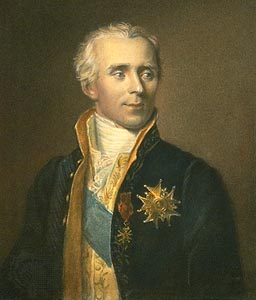
</div>

<div style="text-align: center;">

#### 2.1.1. Discrete-Time Laplace Transform

<div style="text-align: center;">

Let's begin with a discrete, sampled signal $x[t]$.

A question arises, is there a way to weigh each time sample $x$ of $x[t]$ such that the sum of its power-series is finite? Mathematically:

$$
\sum_{t=0}^{\infty} L[t]x^{t}[t] = \mathcal{L}(x[t]) , |\mathcal{L}(x[t])| \lt \infty
$$

* Note, that this sum is often called an **operator** in more advanced discussions of this topic!

$x[t]$ can be re-expressed:

$$
x[t] = (z[t])^{-1}, z[t] \in \mathbb{C}
$$

Let's re-express $z$, since this form means very little intuitively:

$$
z[t] = r[t]e^{j\omega[t]}, \{r[t],\omega[t]\} \in \mathbb{R}^2
$$

Substituting:

$$
\sum_{t=0}^{\infty} L[t] [ (r[t](e^{j \omega[t]}) ]^{-t}
$$

$$
= \sum_{t=0}^{\infty} L[t] r^{-t}[t](e^{-j t \omega[t]})
$$

$$
= \mathcal{L}(r[t],\omega[t]) , |\mathcal{L}(r[t],\omega[t])| \lt \infty
$$

If we assume the constraint that $\omega[t] = \omega_{\nu}$:

$$
\sum_{t=0}^{\infty} L[t] r^{-t}[t] (e^{-j t \omega_{\nu}}) = \mathcal{L}(r[t],\omega_{\nu}) = \mathcal{L}(z[t])
$$

Hopefully, you can see that this is the exact form of the Z-transform.

Ex: Consider that $L[t] = \frac{1}{t!}$, then:

$$
\sum_{t=0}^{\infty} \frac{x^t}{t!} = e^{x} = \mathcal{L}(x)
$$

Therefore, the Discrete Laplace Transform where $L[t] = \frac{1}{t!}$ simply maps:

$$
x[t] \to e^{x[t]}, \forall t
$$

<div style="text-align: center;">

#### 2.1.2 Continuous-Time Laplace Transform

<div style="text-align: center;">

Let's begin with a continuous signal $x(t)$

The same question can be asked again, is there a way to weigh each instantaneous value $x$ of $x(t)$ such that the sum is finite? Mathematically:

$$
\int_{t=0}^{\infty} L(t)x^{t}(t) dt = \mathcal{L}(x(t)), |\mathcal{L}(x(t))|<\infty
$$

For the integral to make sense, there are some conditions, specifically (intuitively): $|x| \in [0,1]$

Let's re-write the expression using $x = e^{\ln(x)}$

$$
\int_{t=0}^{\infty} L(t)(e^{\ln(x(t))})^{t} dt = \mathcal{L}(x(t)), |\mathcal{L}(x(t))|<\infty
$$

Now, $ |\ln(x(t))| \in (-\infty,0]$ but if we insist that $s(t) = -\ln(x(t))$ then:

$$
\int_{t=0}^{\infty} L(t)(e^{-s(t)})^{t} dt = \mathcal{L}(s(t)) \text{ such that } |s(t)| \in [0,\infty)
$$

Let's re-express $s$, since this form means little intuitively:

$$
s(t) = \sigma(t)+j \omega(t), \{ \sigma(t), \omega(t) \} \in \mathbb{R}^2
$$

$$
\int_{t=0}^{\infty} L(t)(e^{-\sigma(t) -j \omega(t)})^{t} dt
$$

$$
= \int_{t=0}^{\infty} L(t)e^{-t \sigma(t)}e^{-j t \omega(t)} dt
$$

$$
= \mathcal{L}(\sigma(t), \omega(t)), |\mathcal{L}(\sigma(t), \omega(t))|<\infty
$$

Assuming that $\omega(t) = \omega_{\nu}$:

$$
\int_{t=0}^{\infty} L(t)e^{- t \sigma(t)}e^{-j t \omega_{\nu}} dt = \mathcal{L}(\sigma(t), \omega_{\nu}) = \mathcal{L}(s(t))
$$

Ex. Consider that $L(t) = e^{-at}$, then:

$$
\int_{n=0}^{\infty} e^{-at} e^{-st} dt = \frac{1}{a+s} = \mathcal{L}(s)
$$

Therefore, the Continuous Laplace Transform where $L(t) = e^{-at}$ simply maps:

$$
x(t) \to \frac{1}{a + \frac{1}{x(t)}}, \forall t
$$

<div style="text-align: center;">

### 2.2. Fourier Transform

<div style="text-align: center;">

#### 2.2.0. Jean-Baptiste Joseph Fourier

<div style="text-align: center;">

Fourier is a mathematician known for his work in heat modeling.

Fourier introduced the Fourier Series while studying the one-dimentional heat equation:

$$
\frac{\partial u}{\partial t} = \alpha^2 \frac{\partial^2 u}{\partial x^2} \text{ where } u(x,t) \text{ was the measured heat at position x and time t.}
$$

Fourier sought separable solutions of the form:

$$
u(x,t) = X(x) T(t)
$$

Substituting this into the heat equation,

$$
X(x) T'(t) = \alpha^2 X''(x) T(t)
$$ 

Re-organizing this equation by dividing by the product $X(x) T(t)$,

$$
\frac{T'(t)}{ \alpha^2 T(t)} = \frac{X''(x)}{X(x)} = -\lambda
$$

* Note that since x and t are independent variables, the only way for these equations to be related, is with a constant.

This means that there are 2 separable Ordinary Differential Equations:

$$
T'(t) + \lambda \alpha^2 T(t) = 0 \to T(t) = C e^{-\lambda \alpha^2 t}
$$

$$
X''(x) +  \lambda X(x) = 0
$$

Fourier considered periodic boundary conditions of the form

$$
X_n(x) = A_n cos(n \pi x / L) + B_n j sin(n \pi x / L) 
$$

Which results in the Fourier series expansion:

$$
u(x,t) = \sum_{n=-\infty}^{\infty} c_n e^{j 2 \pi n x} e^{- \lambda_n \alpha^2 t}
$$

Fourier found that solving PDEs required decomposing functions into sums of exponential components.

Ultimately, Daniel Bernoulli and Leonhard Euler showed that functions were describable trigonometrically, and Joseph-Louis Lagrange explicitly solved the wave equation using a Fourier series.

These mathematicians led him to claim that all signals could be represented using a Fourier series.

<div style="text-align: center;">
    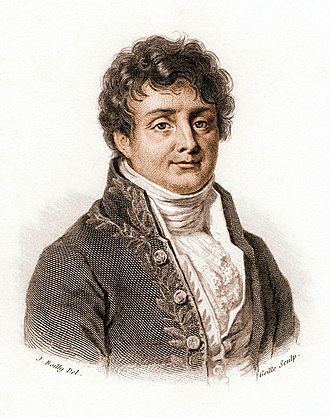
</div>

<div style="text-align: center;">

#### 2.2.1. Discrete-Time Fourier Transform

<div style="text-align: center;">

Let's begin with a discrete, sampled signal $x[t]$.

A question arises, is there a way to weigh each time sample x of $x[t]$ such that the sum of its power-series is finite? Mathematically:

$\sum_{t=0}^{\infty} F[t]x^t = \mathcal{F}(x) , |\mathcal{F}(x)| \lt \infty$

If we constrain $x$ such that $|x| = 1$ then we can substitute $x = e^{-j \omega}$:

$\sum_{t=0}^{\infty} F[t]e^{-j \omega t} = \mathcal{F}(\omega)$

*Notice that this similar to the Discrete-Time Laplace Transform, except that the magnitude is constrained such that it does not fluctuate.*

In order for $|\mathcal{F}(\omega)| \lt \infty$ to be true, $F[t] \in \ell_1$

A simple proof is that $| \mathcal{F}(\omega)| \le \sum_{t=0}^{\infty} |F[t]|$ by triangle-inequality theorem.

<div style="text-align: center;">

#### 2.2.2. Continuous-Time Fourier Transform

<div style="text-align: center;">

Let's begin with a continuous signal $x(t)$

The same question can be asked again, is there a way to weigh each instantaneous value of $x(t)$ such that the sum is finite. Mathematically:

$\int_{t=0}^{\infty} F(t)x^t dt = \mathcal{F}(x)$

For the integral to make sense, there are some conditions, specifically: $|x| \in [0,1]$

If we constrain $x$ such that $|x| = 1$ then we can substitute $x = e^{-j \omega}$:

$\int_{t=0}^{\infty} F(t)e^{-j \omega t} dt = \mathcal{F}(\omega)$

*Notice, again the similarity to the Continuous-Time Laplace transform.*

In order for $|\mathcal{F}(\omega)| < \infty $ to be true, $F(t) \in L_1$

A simple proof is that $|\mathcal{F}(\omega)| \le \int_{t=0}^{\infty} |F(t)| dt $ again, by triangle-inequality theorem.

<div style="text-align: center;">

#### 2.2.3. Discrete Fourier Transform

<div style="text-align: center;">

Let's begin with a discrete signal $x[t]$.

A question arises, is there a way to weigh, $T$ consecutive time samples $x$ of $x[t]$ such that the sum of its power-series is finite? ($T < \infty$) Mathematically:

$\sum_{t=0}^{T-1} F[t]x^t = \mathcal{F}(x) , |\mathcal{F}(x)| \lt \infty$

If we constrain $x$ such that $|x| = 1$ then we can substitute $x = e^{-j \omega}$.

In the case of *DTFT*, $\omega \in [0, \infty)$ by definition, however, by limiting the interpreted signal's length to $T$, it is impossible to determine objective information about the frequency. On the other hand, we can determine information w.r.t. the signal's length.

For *DFT*, define $\hat{\omega} \in \{ 0, \frac{1}{T}, .., \frac{T-1}{T} \}$ then

$\sum_{t=0}^{T-1} F[t]e^{-j \hat{\omega} \frac{t}{T}} = \mathcal{F}(\hat{\omega})$

Clearly, as long as $F[t]<\infty \ \forall t \to |\mathcal{F}(\hat{\omega})| \lt \infty$ because it is a finite sum.

We've shown that $T$ controls the resolution of the signal's frequency content, however the sampling frequency $f_s$ controls the expressable frequency range. Consider:

$t \in \{ 0, T_s, .., (T-1) T_s \} \to \hat{\omega} \in \{ 0, \frac{1}{T_sT},.., \frac{T-1}{T_sT}  \} $

Therefore the *frequency resolution* is $\frac{1}{T_sT} = \frac{f_s}{T}$.

<div style="text-align: center;">

#### 2.2.4. Sampling Theorem

<div style="text-align: center;">

Should this transformation be able to reconstruct the original signal? Consider a continuous-time signal $x(t)$:

$x(t) \in \mathbb{R}$

$ \bar{x}(t) = \sum_{n=-\infty}^{\infty} x(T_sn)\delta(t-T_sn)$

*Note this looks very similar to convolution, specifically discrete convolution*.

$ \mathcal{F} \{  \bar{x}(t) \} = \frac{1}{T_s}  \sum_{n=-\infty}^{\infty} X( \omega) * \mathcal{F} \{ \delta (t-T_sn)\}$

$ \bar{X}(\omega) = \frac{1}{T_s}  \sum_{n=-\infty}^{\infty} X( \omega) * e^{-j \omega T_sn}$

$ \bar{X}(\omega) = \frac{1}{T_s}  \sum_{n=-\infty}^{\infty} X(\omega-n \omega_s)$

Graphically, the signal bandwidth $B | B\le \omega_s$. Moreover, $X(\omega) = X^* (-\omega) \to B\le \frac{\omega_s}{2}$, which is the conclusion made in the Nyquist Theorem!

To ideally reconstruct this signal, we can observe the Sampled Frequency Spectrum $\bar X(\omega)$ and realize that the frequency content outside of the range $-\frac{\omega_s}{2} \le \omega \le \frac{\omega_s}{2}$ is duplicated frequency content, therefore we can filter this out.

This filter is called an anti-aliasing filter, we will learn more about those. We can also apply a gain which is adjusted according to the system's needs.

To apply a filter, all we need to do is multiply the frequency content with a filter of our desire, for demonstration purposes we will define an ideal LPF: $H_{LPF}(\omega) = 1, |\omega| \le B, 0$

*Note: Another common way to express this is using the $\Pi$ function, also known as the square wave function*.

In this case, $B = \frac{\omega_s}{2}$ - to use this in the time domain, we need to apply the inverse Fourier Transform:

$h(t) = \frac{1}{2\pi} \int_{\omega=-\frac{\omega_s}{2}}^{\frac{\omega_s}{2}} 1 e^{j \omega t}d\omega$

$h(t) =  |_{\omega=-\frac{\omega_s}{2}}^{\frac{\omega_s}{2}} \frac{1}{2\pi j t} e^{j \omega t}$

$h(t) = \frac{\frac{f_s}{2}}{j \frac{\omega_s}{2} t} [  e^{j \frac{\omega_s}{2} t} - e^{-j \frac{\omega_s}{2} t} ]$

$h(t) = \frac{\frac{f_s}{2}}{j \frac{\omega_s}{2} t} [  2 j sin(\frac{\omega_s}{2} t) ]$

$h(t) = f_s \frac{sin(\frac{\omega_s}{2} t)}{\frac{\omega_s}{2} t} $

$h(t) = \frac{\omega_s}{2\pi} sinc(\frac{\omega_s}{2}t) $

While we can represent this filter in theory, it cannot exist in practice because it would require $\infty$ taps to represent (and would be computationally expensive to approximate). However, applying an appropriate filter will yield the same *anti-aliasing* effect.

*Note that for reconstruction:*
$ x(t) = \frac{\omega_s}{2} \sum_n x(nT_s) sinc(\frac{\omega_s}{2}(t-nT_s))$
The sinc functions here will be synonymous to the effect of $\delta(t-nT_s)$, since the sinc function will yield a value of 0 for any *other* time sample $kT_s \ne nT_s$

<div style="text-align: center;">

### 2.3. Uncertainty Principle

<div style="text-align: center;">

#### 2.3.1. Implications on Resolution

<div style="text-align: center;">

For a continuous signal $x(t)$, let's define:

$
\\ E_x = \int_{-\infty}^{\infty} |x(t)|^2 dt = \frac{1}{2\pi} \int_{-\infty}^{\infty} |X(\omega)|^2 d\omega$

Assume that $E_x , |E_x|<\infty$ (the signal is *square integrable*).

Let's place some constraints:

$\int_{-\infty}^{\infty} t |x(t)|^2 dt = 0$

$\int_{-\infty}^{\infty} \omega |X(\omega)|^2 d\omega = 0$

Since the function's integral evaluates to 0 the signal energy is centered about $t=0,\omega=0$.

*Note, the constraint takes the exact form of the "mass cumulant" function, which is necessary for calculating the *center of mass* of a function. Recall that:*
$\\
\mathbb{CM}_{f(t)} = \mathbb{CM}[ f(t) ] = \frac{\int_{-\infty}^{\infty} t |f(t)| dt}{\int_{-\infty}^{\infty} |f(t)| dt}
$

Let's define measures of the spread of signal energy:

$\sigma_{t} = \sqrt{\frac{1}{E_x} \int_{-\infty}^{\infty} t^2 |x(t)|^2 dt}$

$\sigma_{\omega} = \sqrt{\frac{1}{2\pi E_x} \int_{-\infty}^{\infty} \omega^2 |X(\omega)|^2 d\omega}$

*Note, this is similar in form to the *standard deviation* of a function.*

We will skip the explicit derivation (If you are interested, wait for the Statistical Signal Processing Workshop), however the important result is that:

$\sigma_t \sigma_{\omega} \ge \frac{1}{2}$ meaning that it is not possible to attain fine resolution in time **and** frequency for any practical signal.

<div style="text-align: center;">

#### 2.3.2. Short-Time Discrete-Time Fourier Transform

<div style="text-align: center;">

Consider applying a DTFT to a Short-Time frame of a signal, then we would see a DTFT of a portion of the signal.

Recall that the finer we make the time resolution, the broader the frequency resolution becomes - therefore, this trade-off is an important constraint to consider for STFT applications, especially Real-Time applications.

Let's allow a time *window* to be controlled by variables $L,m$ which represent the length of the window and the center of the window (respectively), then the STDTFT can be represented:

$X(\omega,m) = \sum_{n=-\infty}^{\infty} x[n] \hat{w}[n-m]e^{-j\omega n}$

In practice, the window location $m$ is iterated in increments proportional to $\sigma_t$. There should be overlap between windows, so $L$ should be big enough to support this.



<div style="text-align: center;">

### 2.4. Fast Fourier Transform

<div style="text-align: center;">

*Fast Fourier Transform* describes a general class of efficient algorithms to calculate DFT and IDFT.

The main idea behind any FFT algorithm is to compute and store calculations that are used repeatedly and algorithmically later.

For an M-point DFT, where $M = \prod_{i=1}^{\nu} p_i$, we can re-arrange the 1-Dimensional signal $x[n]$ into a $\nu$-Dimensional array with corresponding sizes $p_1,p_2,..,p_{\nu}$.

Let's define:

$$
w_M^k = e^{-j \frac{2 \pi k}{M}} \to X_k = \sum_{k=0}^{M-1} x[n] w_M^{kn}
$$

<div style="text-align: center;">

#### 2.4.1. Radix-2 Decimation-in-Time

<div style="text-align: center;">

For Radix-2 Decimation-in-Time, assume that $M = 2^{\nu}$, then further define:

$$
x_{0b}^{(i)}=x_{b}^{(i+1)}[2n]
$$

$$
x_{1b}^{(i)}=x_{b}^{(i+1)}[2n+1]
$$

Additionally, the $2^i$ point DFT of $x_{b}^{(i)}[n]$ is:

$$
\begin{aligned}
  X^{(i)}_{b,k} &=
  \sum_{n=0}^{2^i-1} x^{(i)}_{b}[n] w^{kn}_{2^i}, \quad
  k=0,1,\ldots, 2^i-1.
\end{aligned}
$$

$$
\begin{aligned}
  X^{(i)}_{b,k} &=
  \sum_{n=0}^{2^{i-1}-1} x^{(i)}_{b}[2n] w^{k(2n)}_{2^i} +
  \sum_{n=0}^{2^{i-1}-1} x^{(i)}_{b}[2n+1] w^{k(2n+1)}_{2^i}, \quad
  k=0,1,\ldots, 2^i-1.
\end{aligned}
$$

$$
\begin{aligned}
  X^{(i)}_{b,k} &=
  \sum_{n=0}^{2^{i-1}-1} x^{(i-1)}_{0b}[n] w^{k(n)}_{2^{i-1}} +
  w^{k}_{2^{i}} \sum_{n=0}^{2^{i-1}-1} x^{(i-1)}_{1b}[n] w^{k(n)}_{2^{i-1}}, \quad
  k=0,1,\ldots, 2^i-1.
\end{aligned}
$$


Notice that these are simply $2^{i-1}$-point DFTs, therefore:

$$
\begin{split}\begin{align}
X^{(i)}_{b,k}
& =
X^{(i-1)}_{0b,k} +  w^{k}_{2^i} X^{(i-1)}_{1b,k}
\\
X^{(i)}_{b,k+2^{i-1}}
&=
X^{(i-1)}_{0b,k} +w^{k+2^{i-1}}_{2^i} X^{(i-1)}_{1b,k}
\end{align}\end{split}
$$

This calculation can be expressed:

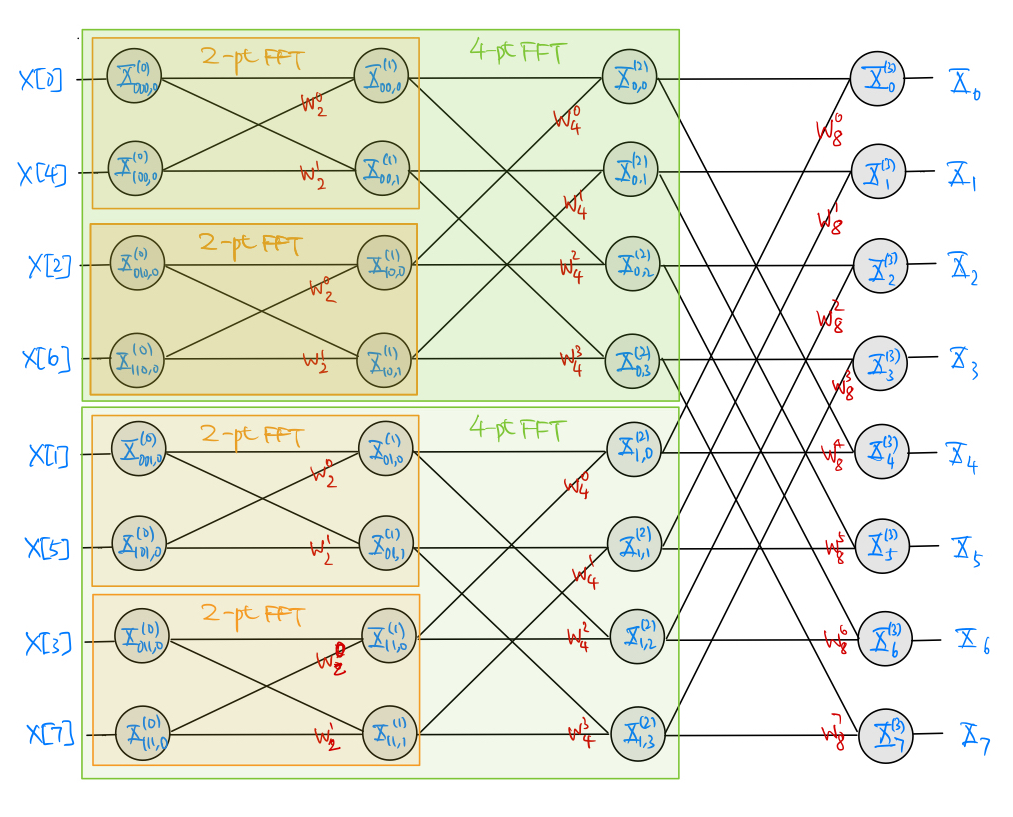

<div style="text-align: center;">

##### **Discrete Fourier Transform**

Computational Complexity: $\mathcal{O}(M^2)$

Storage Complexity: $\mathcal{O}(M)$

##### **Fast Fourier Transform**

Computational Complexity: $\mathcal{O}(M \log_2(M))$

Storage Complexity: $\mathcal{O}(M \log_2(M))$

<div style="text-align: center;">

#### 2.4.2. Radix-2 Decimation-in-Frequency

<div style="text-align: center;">

For Radix-2 Decimation-in-Frequency, assume that $M = 2^{\nu}$, then further define:

$y^{(0)}[n] = x[n]$

$z^{(0)}[n] = w^n_{2^{\nu}}y^{(0)}[n]$

$y^{(i)}_{0b}[n] = y^{(i-1)}_{b}[n] + y^{(i-1)}_{b}[n+2^{\nu-i}]$

$y^{(i)}_{1b}[n] = z^{(i-1)}_{b}[n] + z^{(i-1)}_{b}[n+2^{\nu-i}]$

$z^{(i)}_{0b}[n] = w^n_{2^{\nu-i}} y^{(i)}_{0b}[n]$

$z^{(i)}_{1b}[n] = w^n_{2^{\nu-i}} y^{(i)}_{1b}[n]$

then

\begin{align*}
  Y^{(i)}_{b,k}
  &= \sum_{n=0}^{2^{\nu-i}-1} y^{(i)}_{b}[n] w^{kn}_{2^{\nu-i}}
  & k=0,1,\ldots, 2^{\nu-i}-1.
  \end{align*}

DFT gives

$
X_{2k} = Y^{(0)}_{2k}
\\ = \sum_{n=0}^{2^{\nu}-1} y^{(0)}[n] w^{2kn}_{2^{\nu}}
\\ = \sum_{n=0}^{2^{\nu-1}-1} y^{(0)}[n] w^{kn}_{2^{\nu-1}} + \sum_{n=0}^{2^{\nu-1}-1} y^{(0)}[n+2^{\nu-1}] w^{k(n+2^{\nu-1})}_{2^{\nu-1}}
\\ = \sum_{n=0}^{2^{\nu-1}-1} y^{(1)}_0[n] w^{kn}_{2^{\nu-1}}
\\ = Y^{(1)}_{0,k}
\\ X_{2k+1} = Y^{(0)}_{2k+1}
\\ = \sum_{n=0}^{2^{\nu}-1} y^{(0)}[n] w^{(2k+1)n}_{2^{\nu}}
\\ = \sum_{n=0}^{2^{\nu-1}-1} z^{(0)}[n] w^{kn}_{2^{\nu-1}} + \sum_{n=0}^{2^{\nu-1}-1} z^{(0)}[n+2^{\nu-1}] w^{k(n+2^{\nu-1})}_{2^{\nu-1}}
\\ = \sum_{n=0}^{2^{\nu-1}-1} y^{(1)}_1[n] w^{kn}_{2^{\nu-1}}
\\ = Y^{(1)}_{1,k}
$

Thus

$
\begin{split}\begin{align}
Y^{(i)}_{b,2k} &= Y^{(i+1)}_{0b,k}
\\
Y^{(i)}_{b,2k+1} &= Y^{(i+1)}_{1b,k}
\end{align}\end{split}
$

This calculation can be expressed:

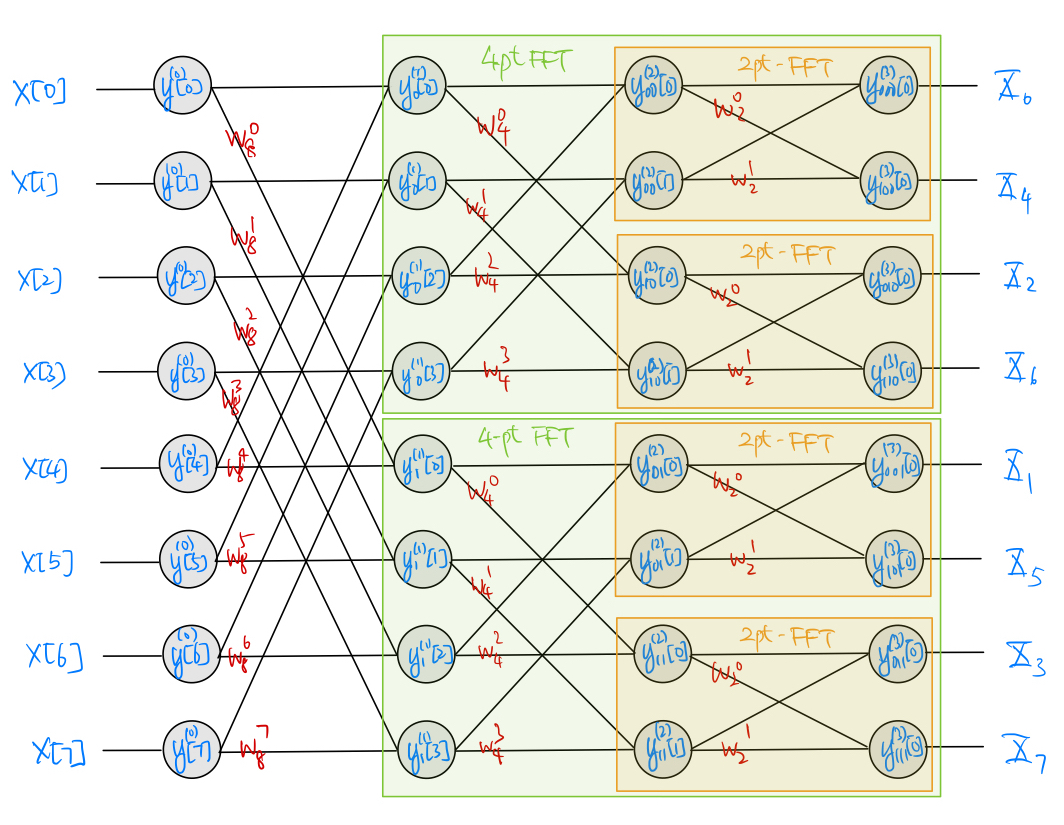

<div style="text-align: center;">

#### 2.4.3. Linear Filtering with FFT

<div style="text-align: center;">

Consider a signal $x[n]$ with length $N$, an FIR Filter $h[n]$ with length $L$. Generally it is assumed that $ N \gg L \gg 1 $

Directly applying $ y[n] = h[n] * x[n]$ will have a length $M = N+L-1$.

The computational complexity will be $\mathcal{O}(NL)$

Consider instead performing the filtering operation in the frequency domain using FFT. This would instead require $\mathcal{O}(M \log_2M)$. A simplification due to $N \gg L \to \mathcal{O}(N \log_2N) $

Therefore, as long as $L \gg \log_2N$, then this approach is useful in speeding up the computations. However, note that the storage complexity will also be $\mathcal{O}(N \log_2N) $ which can be more difficult to justify.

<div style="text-align: center;">

##### 2.4.3.1. Overlap-Add Algorithm

<div style="text-align: center;">

Consider splitting $x[n]$ into portions with length $\hat{N}$ where $N \gg \hat{N} \approx L \gg 1$, then we can apply an $\hat{M}$-point FFT filter on the $\hat{N}$ sized signal, and add the results of each block-level filter.

This process on the entire signal thus becomes $\mathcal{O}(N \log_2L)$ which is advantageous as long as $L \gg 1$. Furthermore, for Real-Time Processes, the $\mathcal{O}(NL)$ latency is reduced to $\mathcal{O}(L)$.

Visual:

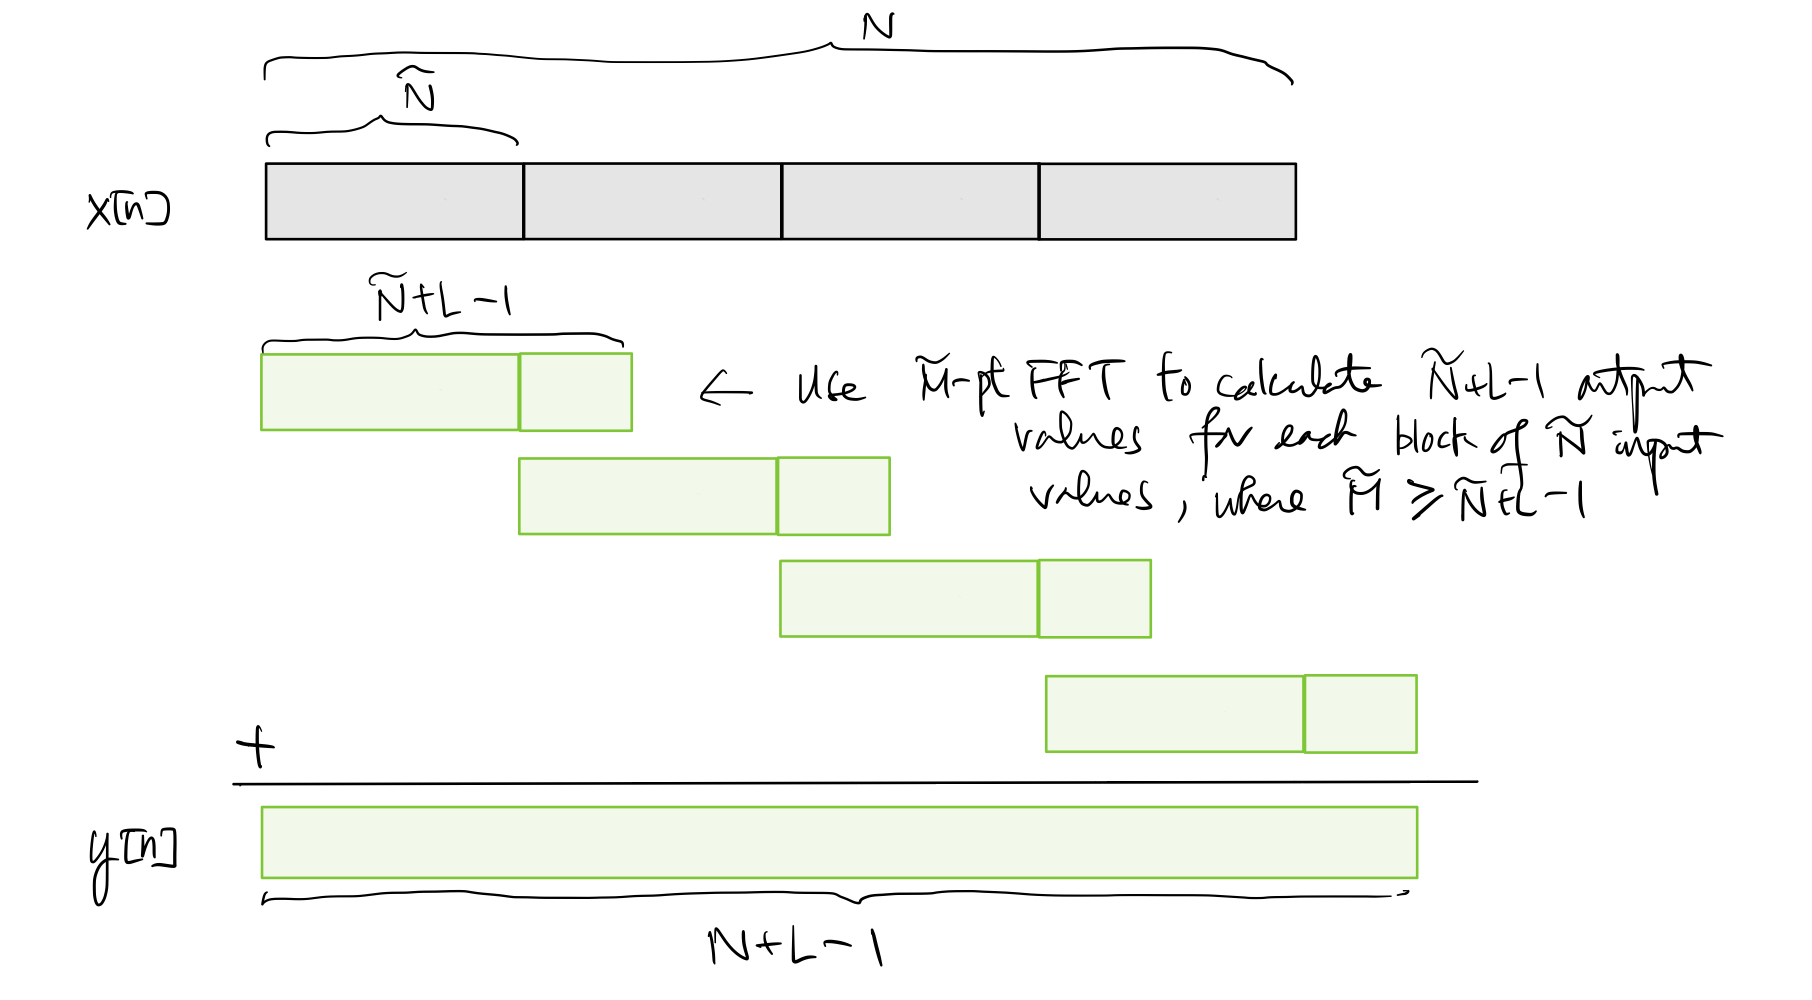

<div style="text-align: center;">

##### 2.4.3.2. Overlap-Save Algorithm

<div style="text-align: center;">

Consider splitting $x[n]$ into portions with length $\hat{N}$ where $\hat{M} = \hat{N} + L -1$, then we can apply an $\hat{M}$-point FFT filter on the $\hat{N}$ sized signal, and add the results, excluding the initial $L-1$ output of the FFT to the output signal.

This algorithm will have the same complexity properties as the *Overlap-Add* Algorithm.

Visual:

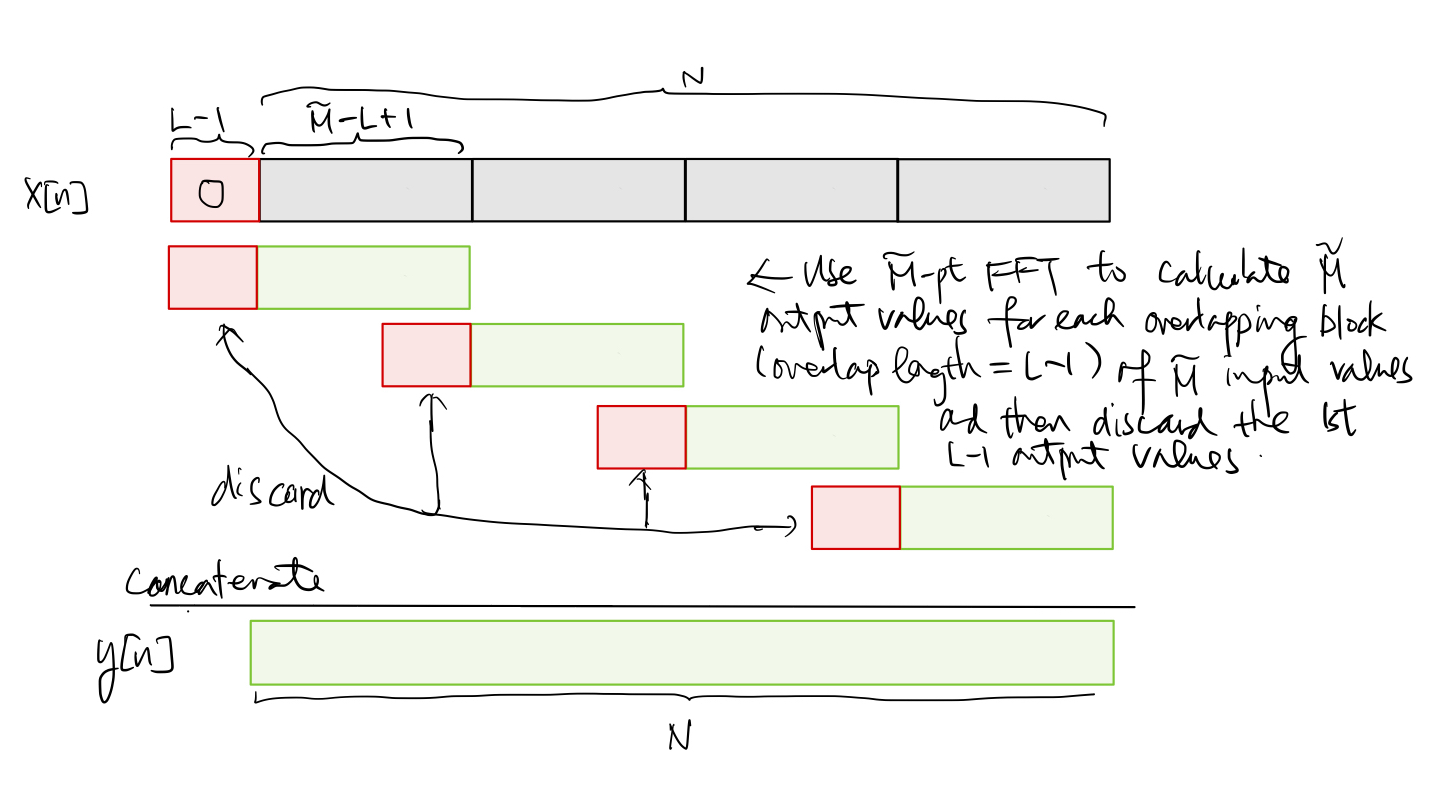